In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from plotnine import *


In [2]:
product_df = pd.read_csv('../Datasets/Exercise2_datasets/extdata 3/example_product_data.csv')
product_df.head()

,name,producta,productb
0,John Doe,NaN,12
1,Marry Doe,3.0,1
2,John Johnson,5.0,1


In [7]:
melted_product = product_df.melt(id_vars= 'name', value_vars= ['producta','productb'], value_name= 'count', var_name= 'product')

melted_product

,name,product,count
0,John Doe,producta,NaN
1,Marry Doe,producta,3.0
2,John Johnson,producta,5.0
3,John Doe,productb,12.0
4,Marry Doe,productb,1.0
5,John Johnson,productb,1.0


In [23]:
pivot_product = melted_product.pivot(index = 'name', columns= 'product', values= 'count').reset_index()

pivot_product.columns.name = None
pivot_product

,name,producta,productb
0,John Doe,NaN,12.0
1,John Johnson,5.0,1.0
2,Marry Doe,3.0,1.0


----

# Section 2- Merge Warm Up

Prepare two tables by running the following code:

In [35]:
import statsmodels.api as sm

mtcars = sm.datasets.get_rdataset("mtcars", "datasets", cache=True).data

mtcars.index.name = "carname"
mtcars = mtcars.reset_index() #(0, "model", mtcars.index)

df1 = mtcars.iloc[4:25][['carname', 'mpg', 'cyl']]
df2 = mtcars.iloc[0:10][['carname', 'gear']]

In [36]:
df1.head()

,carname,mpg,cyl
4,Hornet Sportabout,18.7,8
5,Valiant,18.1,6
6,Duster 360,14.3,8
7,Merc 240D,24.4,4
8,Merc 230,22.8,4


In [37]:
df2.head()

,carname,gear
0,Mazda RX4,4
1,Mazda RX4 Wag,4
2,Datsun 710,4
3,Hornet 4 Drive,3
4,Hornet Sportabout,3


1. How many rows does the inner merge of df1 and df2 have?

In [46]:
pd.merge(df1, df2, how= 'inner', on= 'carname').shape[0]

6

2. How many rows does the left merge of df1 and df2 have?

In [47]:
pd.merge(df1,df2, how = 'left', on = 'carname').shape[0]

21

3. How many rows does the outer merge of df1 and df2 have?

In [51]:
pd.merge(df1, df2, how = 'outer', on = 'carname').shape[0]

25

--------

# Section 03 - Weather dataset

1. Read in the weather dataset weather.txt as a pandas.DataFrame. Please find this file on Moodle
and save it to a folder called extdata in your working directory.

In [90]:
messy_df = pd.read_csv('../Datasets/Exercise2_datasets/extdata 3/weather.txt')
messy_df.head()

,"id\t""year""\t""month""\t""element""\t""d1""\t""d2""\t""d3""\t""d4""\t""d5""\t""d6""\t""d7""\t""d8""\t""d9""\t""d10""\t""d11""\t""d12""\t""d13""\t""d14""\t""d15""\t""d16""\t""d17""\t""d18""\t""d19""\t""d20""\t""d21""\t""d22""\t""d23""\t""d24""\t""d25""\t""d26""\t""d27""\t""d28""\t""d29""\t""d30""\t""d31"""
0,"MX000017004\t2010\t1\t""TMAX""\tNA\tNA\tNA\tNA\t..."
1,"MX000017004\t2010\t1\t""TMIN""\tNA\tNA\tNA\tNA\t..."
2,"MX000017004\t2010\t2\t""TMAX""\tNA\t273\t241\tNA..."
3,"MX000017004\t2010\t2\t""TMIN""\tNA\t144\t144\tNA..."
4,"MX000017004\t2010\t3\t""TMAX""\tNA\tNA\tNA\tNA\t..."


In [91]:
messy_df = pd.read_csv('../Datasets/Exercise2_datasets/extdata 3/weather.txt', sep = '\t')
messy_df.head()

,id,year,month,element,d1,d2,d3,d4,d5,d6,...,d22,d23,d24,d25,d26,d27,d28,d29,d30,d31
0,MX000017004,2010,1,TMAX,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,278.0,NaN
1,MX000017004,2010,1,TMIN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,145.0,NaN
2,MX000017004,2010,2,TMAX,NaN,273.0,241.0,NaN,NaN,NaN,...,NaN,299.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MX000017004,2010,2,TMIN,NaN,144.0,144.0,NaN,NaN,NaN,...,NaN,107.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MX000017004,2010,3,TMAX,NaN,NaN,NaN,NaN,321.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
messy_df1 = messy_df.melt(id_vars= ['id','year', 'month', 'element'], value_name= 'temp', var_name= 'day')

messy_df1.head()

,id,year,month,element,day,temp
0,MX000017004,2010,1,TMAX,d1,NaN
1,MX000017004,2010,1,TMIN,d1,NaN
2,MX000017004,2010,2,TMAX,d1,NaN
3,MX000017004,2010,2,TMIN,d1,NaN
4,MX000017004,2010,3,TMAX,d1,NaN


In [93]:
messy_df1['day'] = messy_df1['day'].str.replace('d', '')

messy_df1['date'] = messy_df1['year'].astype('str') + \
                '-' + messy_df1['month'].astype('str') + \
                '-' + messy_df1['day'].astype('str') 

messy_df1.head()

,id,year,month,element,day,temp,date
0,MX000017004,2010,1,TMAX,1,NaN,2010-1-1
1,MX000017004,2010,1,TMIN,1,NaN,2010-1-1
2,MX000017004,2010,2,TMAX,1,NaN,2010-2-1
3,MX000017004,2010,2,TMIN,1,NaN,2010-2-1
4,MX000017004,2010,3,TMAX,1,NaN,2010-3-1


In [94]:
messy_df1.drop(columns= ['year', 'month', 'day'], inplace= True)
messy_df1.head()

,id,element,temp,date
0,MX000017004,TMAX,NaN,2010-1-1
1,MX000017004,TMIN,NaN,2010-1-1
2,MX000017004,TMAX,NaN,2010-2-1
3,MX000017004,TMIN,NaN,2010-2-1
4,MX000017004,TMAX,NaN,2010-3-1


In [95]:
messy_df1 = messy_df1.pivot(index= ['id', 'date'], columns = 'element', values= 'temp').reset_index().sort_values(by = 'date')
messy_df1.head()

element,id,date,TMAX,TMIN
0,MX000017004,2010-1-1,NaN,NaN
1,MX000017004,2010-1-10,NaN,NaN
2,MX000017004,2010-1-11,NaN,NaN
3,MX000017004,2010-1-12,NaN,NaN
4,MX000017004,2010-1-13,NaN,NaN


In [97]:
messy_df1.dropna(subset= ['TMAX', 'TMIN'], how= 'all').head()

element,id,date,TMAX,TMIN
23,MX000017004,2010-1-30,278.0,145.0
36,MX000017004,2010-10-14,295.0,130.0
37,MX000017004,2010-10-15,287.0,105.0
51,MX000017004,2010-10-28,312.0,150.0
57,MX000017004,2010-10-5,270.0,140.0


-----

# Homework

# Section 04 -Scattered data across many files

The baby-names folder contains 258 csv-files (1999.girl.csv, 1999.boy.csv , …) which store name
frequencies for a particular year and sex.

1. Create a list containing all file paths in the folder, i.e. (extdata/baby-names/1999.girl.csv,
extdata/baby-names/1999.boys.csv, …). Refer to Appendix A of the script if you are having trouble
with the file paths.

In [121]:
import glob

files = glob.glob('../Datasets/Exercise2_datasets/extdata 3/baby-names/*.csv')

In [122]:
pd.read_csv(files[0]).head()

,name,percent
0,Jacob,0.016514
1,Michael,0.015346
2,Matthew,0.013695
3,Joshua,0.013194
4,Christopher,0.011990


2. Read multiple CSV files into pandas and combine them into a single DataFrame. - For each file in
the list, read its contents into a DataFrame and add a new column containing the file’s name (e.g.,
“1999.girl.csv”). - Combine all individual DataFrames into one large table.

In [123]:
dfs = []

for i in range(len(files)):
    df = pd.read_csv(files[i]).assign(file_name = files[i].split('/')[-1])
    dfs.append(df)

df = pd.concat(dfs, ignore_index= True)
df.head()

,name,percent,file_name
0,Jacob,0.016514,2000.boy.csv
1,Michael,0.015346,2000.boy.csv
2,Matthew,0.013695,2000.boy.csv
3,Joshua,0.013194,2000.boy.csv
4,Christopher,0.011990,2000.boy.csv


4. Is the data tidy? If not, tidy it up.

In [126]:
df[['year', 'sex']] = df['file_name'].str.replace('.csv', '').str.split('.', n = 1, expand= True)

In [129]:
df.drop(columns = 'file_name', inplace = True)
df.head()

,name,percent,year,sex
0,Jacob,0.016514,2000,boy
1,Michael,0.015346,2000,boy
2,Matthew,0.013695,2000,boy
3,Joshua,0.013194,2000,boy
4,Christopher,0.011990,2000,boy


In [130]:
df.dtypes

name        object
percent    float64
year        object
sex         object
dtype: object

In [136]:
df['year'] = df['year'].astype('Int64')
df['sex'] = df['sex'].astype('category')

In [138]:
df['sex'].dtype

CategoricalDtype(categories=['boy', 'girl'], ordered=False, categories_dtype=object)

--------

# Section 05 - Small case-study: tidying up the yeast growth dataset

In this section, we will create a tidy data table from the dataset of the paper:

* Gagneur, Julien, et al. “Genotype-environment interactions reveal causal pathways that mediate
genetic effects on phenotype.” PLoS Genet 9.9 (2013): e1003803. https://journals.plos.org/plosgenetics/article?id=10.1371/journal.pgen.1003803

You will not need to understand the data in depth for this exercise but if you are interested you can find
a detailed description in section 7.1 of the script.

1. Read in the two files in the folder eqtl.

In [153]:
gt = pd.read_csv('../Datasets/Exercise2_datasets/extdata 3/eqtl/genotype.txt', sep = '\t')
display(gt.head())

growth = pd.read_csv('../Datasets/Exercise2_datasets/extdata 3/eqtl/growth.txt', sep = '\t')
display(growth.head())

,strain,mrk_1,mrk_14,mrk_27,mrk_40,mrk_54,mrk_67,mrk_80,mrk_94,mrk_107,...,mrk_13194,mrk_13207,mrk_13220,mrk_13234,mrk_13247,mrk_13260,mrk_13274,mrk_13287,mrk_13300,mrk_13314
0,seg_01B,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,...,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain
1,seg_01C,Wild isolate,Wild isolate,Wild isolate,Wild isolate,Wild isolate,Lab strain,Wild isolate,Wild isolate,Wild isolate,...,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain
2,seg_01D,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Wild isolate,Wild isolate,Wild isolate,Wild isolate,...,Wild isolate,Wild isolate,Wild isolate,Wild isolate,Wild isolate,Wild isolate,Wild isolate,Wild isolate,Wild isolate,Wild isolate
3,seg_02B,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,...,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain
4,seg_02C,Wild isolate,Wild isolate,Wild isolate,Lab strain,Lab strain,Lab strain,Lab strain,Lab strain,Wild isolate,...,Wild isolate,Wild isolate,Wild isolate,Wild isolate,Wild isolate,Wild isolate,Wild isolate,Wild isolate,Wild isolate,Wild isolate


,strain,YPD,YPD_BPS,YPD_Rapa,YPE,YPMalt
0,seg_01B,12.603986,10.460795,2.500311,5.265698,6.720447
1,seg_01C,10.791144,11.632019,NaN,5.365259,7.429273
2,seg_01D,12.817268,10.423287,3.142154,5.577932,6.905589
3,seg_02B,10.299210,9.103611,4.314388,3.257843,4.924324
4,seg_02C,11.132778,9.263100,3.548543,3.815689,4.413402


2. Come up with a strategy, how you can transform the two tables shown above into the single table
shown below.

In [156]:
growth_melt = growth.melt(id_vars= 'strain', var_name= 'media', value_name= 'val')
display(growth_melt.head())

gt_melt = gt.melt(id_vars= 'strain', var_name = 'marker', value_name= 'gt')
display(gt_melt.head())

gt_growth = pd.merge(growth_melt, gt_melt, on = 'strain', how = 'outer')
display(gt_growth.head())

,strain,media,val
0,seg_01B,YPD,12.603986
1,seg_01C,YPD,10.791144
2,seg_01D,YPD,12.817268
3,seg_02B,YPD,10.299210
4,seg_02C,YPD,11.132778


,strain,marker,gt
0,seg_01B,mrk_1,Lab strain
1,seg_01C,mrk_1,Wild isolate
2,seg_01D,mrk_1,Lab strain
3,seg_02B,mrk_1,Lab strain
4,seg_02C,mrk_1,Wild isolate


,strain,media,val,marker,gt
0,seg_01B,YPD,12.603986,mrk_1,Lab strain
1,seg_01B,YPD,12.603986,mrk_14,Lab strain
2,seg_01B,YPD,12.603986,mrk_27,Lab strain
3,seg_01B,YPD,12.603986,mrk_40,Lab strain
4,seg_01B,YPD,12.603986,mrk_54,Lab strain


4. Spoiler: These are the things you can do with tidy data. When you are done run the following line of
code and observe the result:

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 84 rows containing non-finite values.


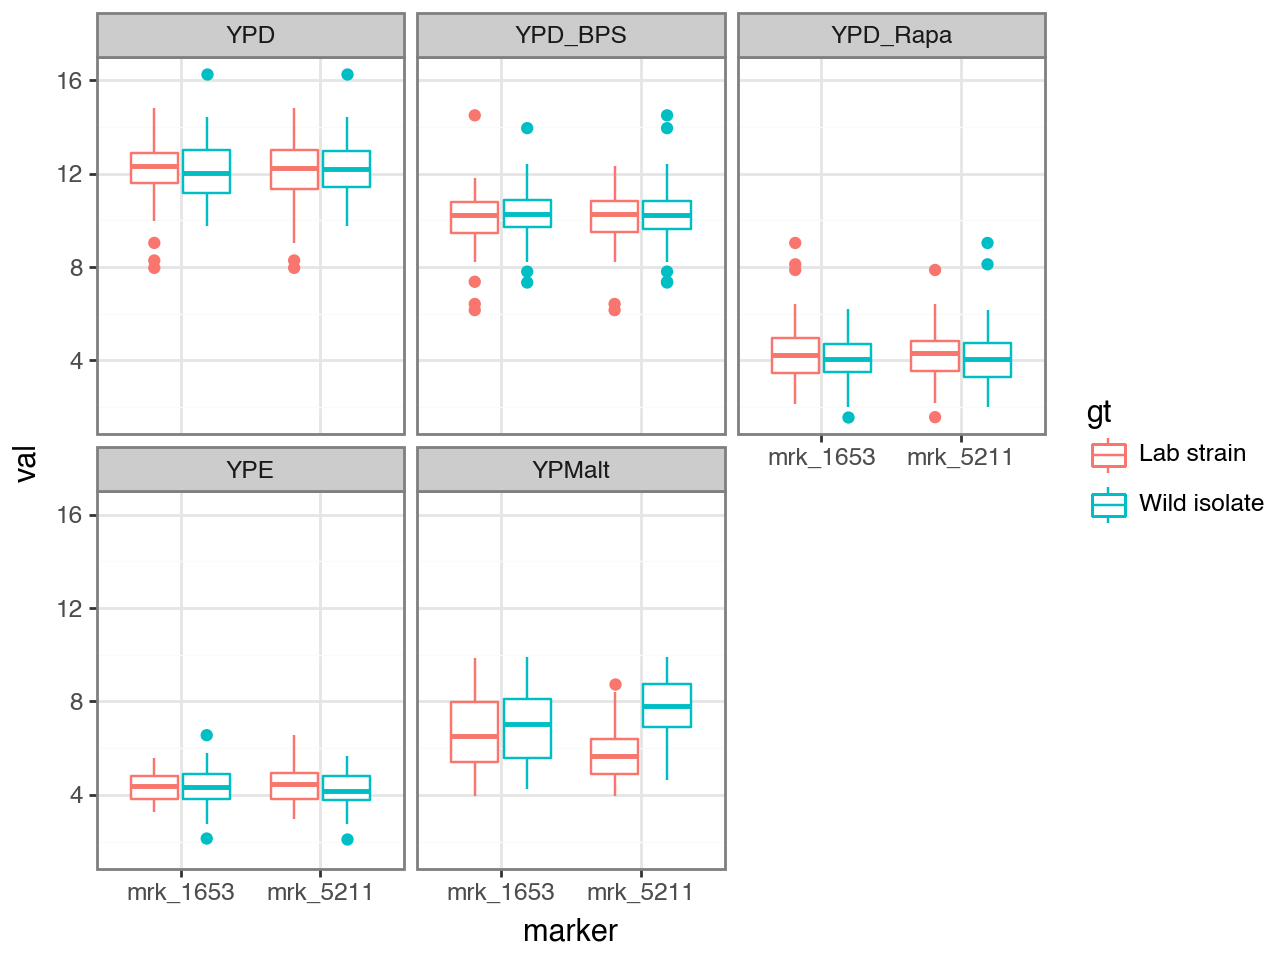

In [160]:
subset = gt_growth[gt_growth["marker"].isin(["mrk_5211", "mrk_1653"])]

(
ggplot(subset, aes(x="marker", y="val", color="gt"))
+ geom_boxplot()
+ facet_wrap("~media")
+ theme_bw()
)